In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd

# Ruta del archivo ROOT
file_path = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251126.root"

# Abrir el archivo
root_file = uproot.open(file_path)

# Mostrar los árboles que contiene
print("Árboles y claves en el ROOT file:")
for key in root_file.keys():
    print(key)


Árboles y claves en el ROOT file:
peak;3
spectrum;2
temp;2


In [2]:
import uproot
root_file = uproot.open("/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251126.root")

# Árboles principales
trees = ["peak", "spectrum", "temp"]

for tree_name in trees:
    tree = root_file[tree_name]
    print(f"Ramas en el árbol '{tree_name}':")
    print(tree.keys())
    print("-"*40)


Ramas en el árbol 'peak':
['t', 'wav', 'sweep', 'ch', 'pos']
----------------------------------------
Ramas en el árbol 'spectrum':
['t', 'wav']
----------------------------------------
Ramas en el árbol 'temp':
['t', 'temp']
----------------------------------------


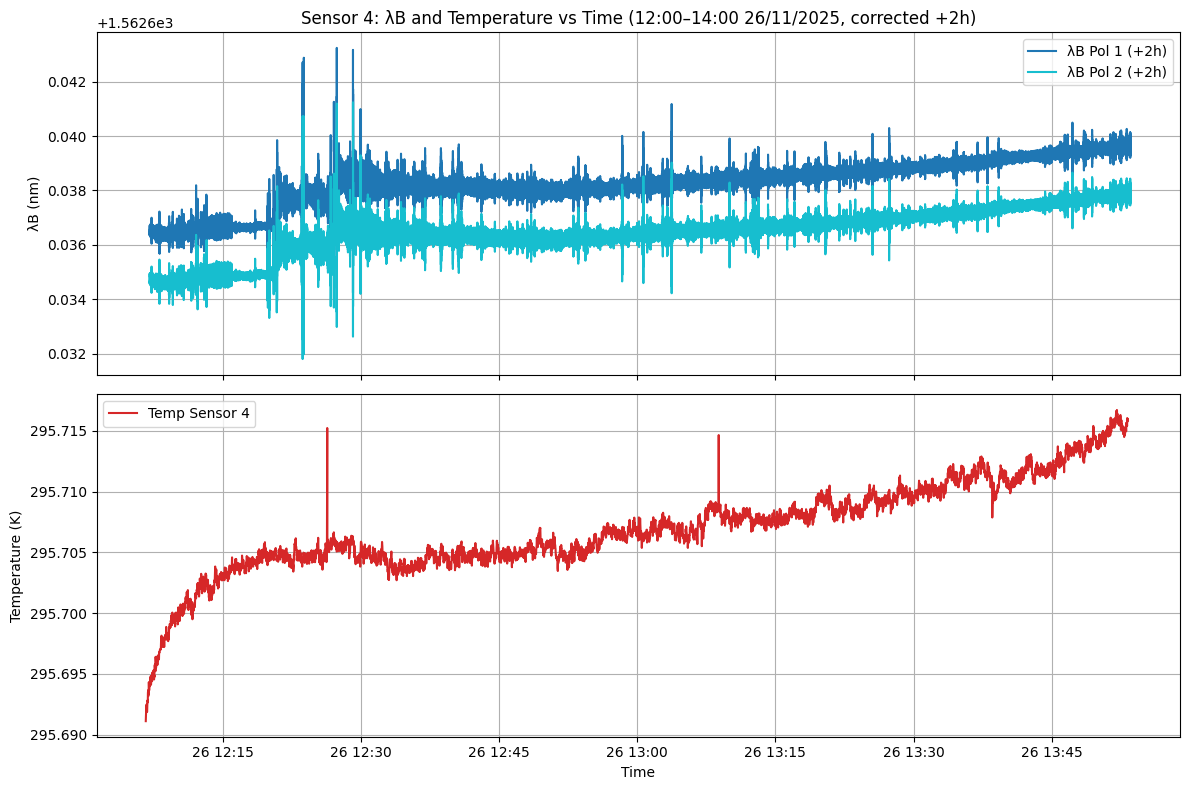

In [5]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Abrir archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251126.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 5 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 3]
sensor3_pol2 = peak_data["wav"][:, 1, 3]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 3]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- 💡 Corregir desfase: sumar 2 horas a los tiempos de peak ---
time_shift = datetime.timedelta(hours=2) - datetime.timedelta(minutes=1)
peak_timestamps = peak_timestamps + time_shift

# --- Definir filtro temporal ---
start_time = datetime.datetime(2025, 11, 26, 12, 0, 0)
end_time   = datetime.datetime(2025, 11, 26, 14, 0, 0)

# --- Aplicar máscaras ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Graficar en dos subplots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# λB
ax1.plot(peak_t_filtered, sensor3_pol1_filtered*1e9, label="λB Pol 1 (+2h)", color="tab:blue")
ax1.plot(peak_t_filtered, sensor3_pol2_filtered*1e9, label="λB Pol 2 (+2h)", color="tab:cyan")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 4: λB and Temperature vs Time (12:00–14:00 26/11/2025, corrected +2h)")
ax1.legend()
ax1.grid(True)

# Temperatura
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Temp Sensor 4", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


---- DATA TIME INTERVALS ----
Peak data (+2h): 2025-11-26 12:08:04.876027  →  2025-11-26 13:54:34.874709
Temp data:       2025-11-26 12:06:39  →  2025-11-26 13:53:15
--------------------------------


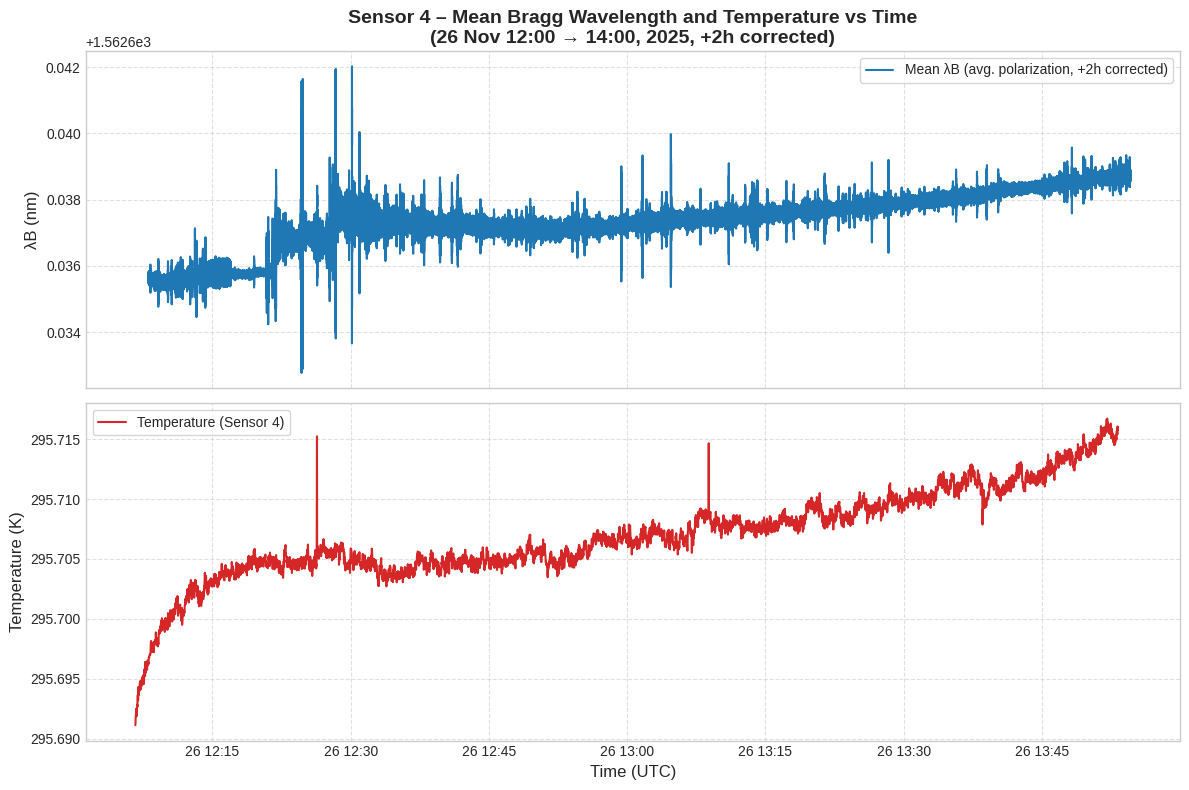

In [6]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251126.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 data ---
peak_times = peak_data["t"][:, 0]           # first polarization
sensor3_pol1 = peak_data["wav"][:, 0, 3]
sensor3_pol2 = peak_data["wav"][:, 1, 3]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 3]

# --- Convert timestamps to datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Print intervals for confirmation ---
print("---- DATA TIME INTERVALS ----")
print(f"Peak data (+2h): {peak_timestamps.min()}  →  {peak_timestamps.max()}")
print(f"Temp data:       {temp_timestamps.min()}  →  {temp_timestamps.max()}")
print("--------------------------------")

# --- Define time window ---
start_time = datetime.datetime(2025, 11, 26, 12, 0, 0)
end_time   = datetime.datetime(2025, 11, 26, 14, 0, 0)

# --- Apply time masks ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Compute average Bragg wavelength (λB) between polarizations ---
sensor3_mean = (sensor3_pol1_filtered + sensor3_pol2_filtered) / 2

# --- Plot: λB and Temperature vs Time ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- λB average ---
ax1.plot(peak_t_filtered, sensor3_mean * 1e9, label="Mean λB (avg. polarization, +2h corrected)",
         color="tab:blue", linewidth=1.5)
ax1.set_ylabel("λB (nm)", fontsize=12)
ax1.set_title("Sensor 4 – Mean Bragg Wavelength and Temperature vs Time\n(26 Nov 12:00 → 14:00, 2025, +2h corrected)",
              fontsize=14, weight='bold')
ax1.legend(frameon=True)
ax1.grid(True, linestyle="--", alpha=0.6)

# --- Temperature ---
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Temperature (Sensor 4)", color="tab:red", linewidth=1.5)
ax2.set_xlabel("Time (UTC)", fontsize=12)
ax2.set_ylabel("Temperature (K)", fontsize=12)
ax2.legend(frameon=True)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


---- DATA TIME INTERVALS ----
Peak data (+2h): 2025-11-26 12:08:04.876027107  →  2025-11-26 13:54:34.874708891
Temp data:       2025-11-26 12:06:39  →  2025-11-26 13:53:15
--------------------------------


===== SENSOR 1 =====
λB range: 1545.145–1545.154 nm
T range:  296.43–296.53 K
Fit data points: 53
x mean ± std: 296.479 ± 0.026 K
y mean ± std: 1545150.525 ± 1.327 pm
Fit slope = 5.6933e+01 pm/K, Intercept = 1.5283e+06 pm

===== SENSOR 3 =====
λB range: 1556.794–1556.803 nm
T range:  296.11–296.15 K
Fit data points: 53
x mean ± std: 296.134 ± 0.006 K
y mean ± std: 1556798.362 ± 0.767 pm
Fit slope = 1.4192e+02 pm/K, Intercept = 1.5148e+06 pm

===== SENSOR 4 =====
λB range: 1562.633–1562.642 nm
T range:  295.69–295.72 K
Fit data points: 53
x mean ± std: 295.707 ± 0.004 K
y mean ± std: 1562637.354 ± 0.790 pm
Fit slope = 2.6682e+02 pm/K, Intercept = 1.4837e+06 pm

===== SENSOR 5 =====
λB range: 0.000–0.000 nm
T range:  295.51–295.53 K
Fit data points: 53
x mean ± std: 295.518 ± 0.001 K


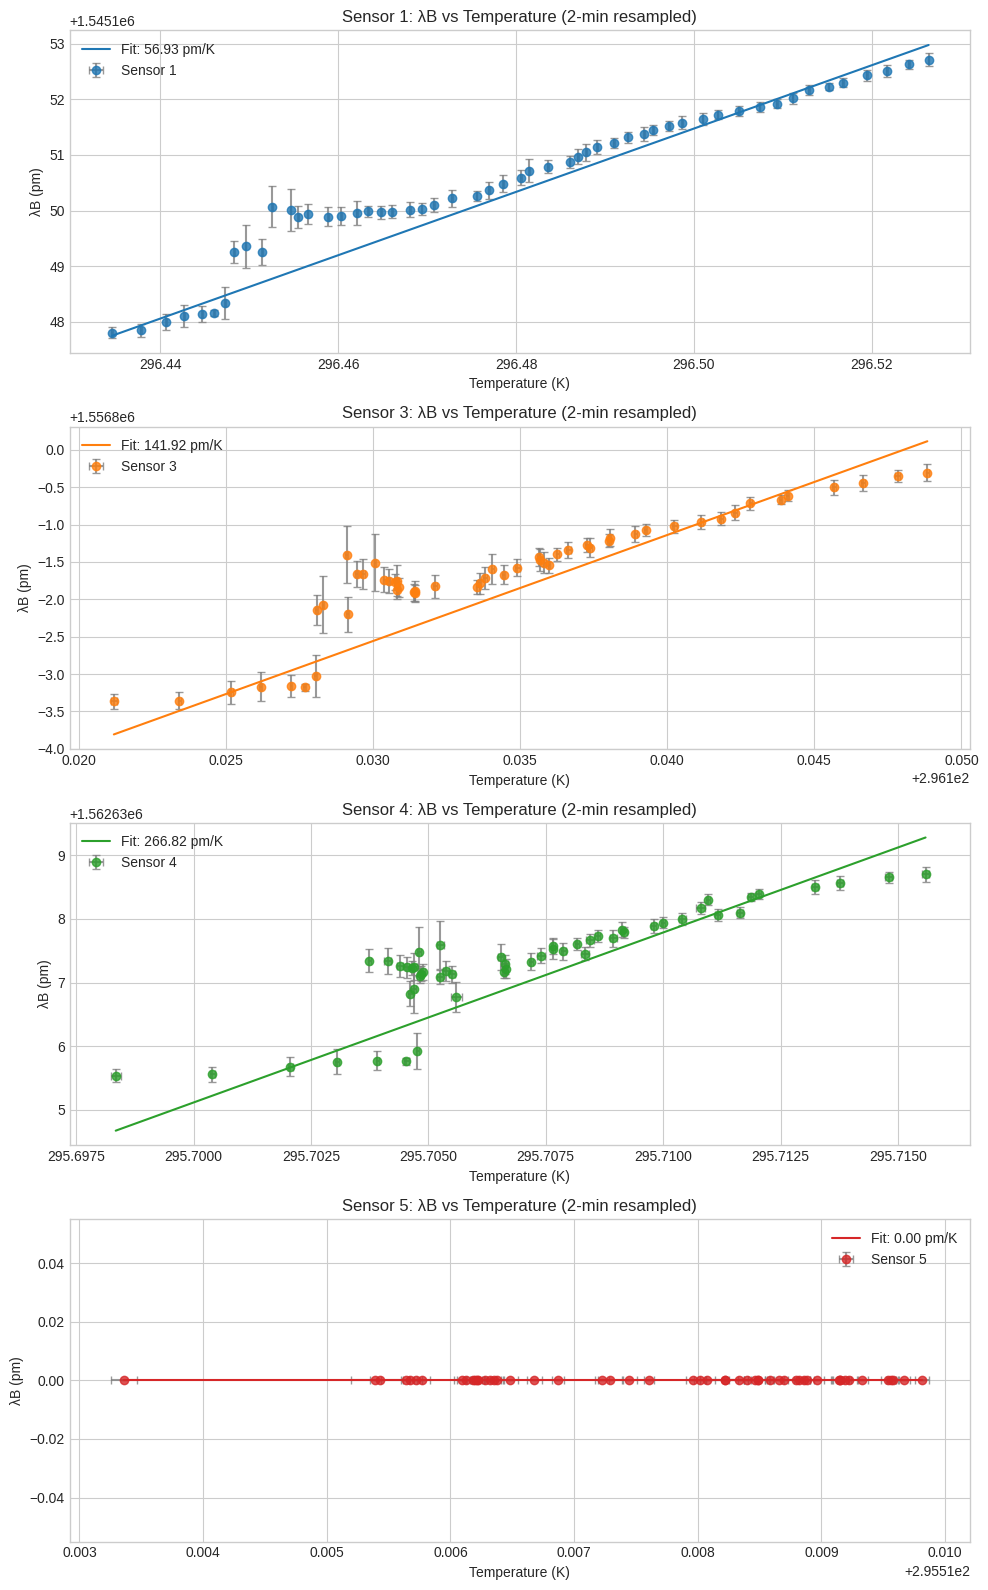

In [7]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251126.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensors to analyze (1,3,4,5) ---
sensors = [0, 2, 3, 4]

# --- Convert timestamps ---
peak_times = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_times = pd.to_datetime(temp_data["t"], unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_times = peak_times + time_shift

# --- Print data intervals for sanity check ---
print("---- DATA TIME INTERVALS ----")
print(f"Peak data (+2h): {peak_times.min()}  →  {peak_times.max()}")
print(f"Temp data:       {temp_times.min()}  →  {temp_times.max()}")
print("--------------------------------\n")

# --- Time window ---
start_time = datetime.datetime(2025, 11, 26, 12, 0, 0)
end_time   = datetime.datetime(2025, 11, 26, 14, 0, 0)

mask_peak = (peak_times >= start_time) & (peak_times <= end_time)
mask_temp = (temp_times >= start_time) & (temp_times <= end_time)

peak_t_filtered = peak_times[mask_peak]
temp_t_filtered = temp_times[mask_temp]

# --- Fixed colors per sensor ---
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# --- Create figure ---
fig, axes = plt.subplots(len(sensors), 1, figsize=(10, 16))

for i, sensor in enumerate(sensors):
    print(f"\n===== SENSOR {sensor+1} =====")
    
    # Average λB from both polarizations (meters -> nm)
    lambdaB_m = (peak_data["wav"][:, 0, sensor] + peak_data["wav"][:, 1, sensor]) / 2  # meters
    lambdaB_nm = lambdaB_m * 1e9  # nanometers
    lambdaB_filtered = lambdaB_nm[mask_peak]
    
    # Quick check of magnitude
    print(f"λB range: {lambdaB_filtered.min():.3f}–{lambdaB_filtered.max():.3f} nm")
    
    # Temperature
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    print(f"T range:  {temp_filtered.min():.2f}–{temp_filtered.max():.2f} K")

    # DataFrames
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered}, index=peak_t_filtered)
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)
    
    # Resample every 2 minutes → mean & std
    peak_resampled = df_peak.resample("2min").agg(["mean","std"])
    temp_resampled = df_temp.resample("2min").agg(["mean","std"])
    
    # Standard error of the mean
    peak_resampled['lambdaB_nm','se'] = peak_resampled['lambdaB_nm','std'] / np.sqrt(df_peak.resample("2min").count()['lambdaB_nm'])
    temp_resampled['temp_K','se'] = temp_resampled['temp_K','std'] / np.sqrt(df_temp.resample("2min").count()['temp_K'])
    
    # Merge and drop NaN
    df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()
    
    # --- Weighted linear fit but with swapped axes: x = Temperature (K), y = λB (pm) ---
    # Convert λB to pm for y
    x = df_combined['temp_K','mean'].values            # K (x-axis)
    y = df_combined['lambdaB_nm','mean'].values * 1e3  # pm (y-axis)

    # uncertainties on y (lambdaB) converted to pm
    yerr = df_combined['lambdaB_nm','std'].values * 1e3  # pm
    # x uncertainties for plotting (optional)
    xerr = df_combined['temp_K','se'].values

    # Basic sanity check
    print(f"Fit data points: {len(x)}")
    if len(x) > 0:
        print(f"x mean ± std: {np.mean(x):.3f} ± {np.std(x):.3f} K")
        print(f"y mean ± std: {np.mean(y):.3f} ± {np.std(y):.3f} pm")

    # avoid zero-division in weights
    if np.all(yerr == 0) or len(yerr)==0:
        w = None
        slope, intercept = np.polyfit(x, y, 1)
    else:
        yerr_safe = np.where(yerr == 0, np.mean(yerr[yerr>0]) if np.any(yerr>0) else 1.0, yerr)
        w = 1.0 / (yerr_safe ** 2)
        slope, intercept = np.polyfit(x, y, 1, w=w)

    # slope is in pm/K directly
    print(f"Fit slope = {slope:.4e} pm/K, Intercept = {intercept:.4e} pm")

    # Plot: Temperature on x, λB on y (pm)
    ax = axes[i]
    ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', color=colors[i], ecolor='gray', capsize=3, alpha=0.8, label=f"Sensor {sensor+1}")

    # plot fit line over sorted x for nicer visualization
    if len(x) > 0:
        x_sort_idx = np.argsort(x)
        x_sorted = x[x_sort_idx]
        ax.plot(x_sorted, slope * x_sorted + intercept, '-', color=colors[i], label=f"Fit: {slope:.2f} pm/K")

    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("λB (pm)")
    ax.set_title(f"Sensor {sensor+1}: λB vs Temperature (2-min resampled)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()